# Generative Models: GANs and Diffusion

**Deep Learning - University of Vermont**

---

In this coding session, you will learn the following:

1. **Build a GAN Architecture**: Implement two competing networks (Generator and Discriminator) using transposed convolutions and strided convolutions.
2. **Minimax Loss Implementation**: Code the adversarial Binary Cross-Entropy objective where the Discriminator maximises correct labelling and the Generator minimises it.
3. **Forward Diffusion Process**: Implement the closed-form, single-step corruption of images via a fixed linear variance schedule.
4. **Reverse Diffusion with U-Net**: Construct a U-Net that predicts and removes noise at each timestep using residual blocks and skip connections.
5. **Conditioning Techniques**: Implement classifier-free guidance (CFG) for class-conditional generation without a separate classifier network.
6. **Architectural Comparison**: Summarise GAN training dynamics (adversarial) vs. Diffusion training dynamics (denoising), focusing on stability, diversity, and sampling speed.

## Setup and Imports

We import standard PyTorch libraries and set global seeds for reproducibility.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import math

# ── Device configuration ──────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ── Reproducibility ───────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


---
## 1. Build a GAN Architecture

GANs pit two networks against each other in a two-player zero-sum game:

| Network | Role |
|---|---|
| **Generator** $G$ | Takes random noise $\mathbf{z} \sim \mathcal{N}(0,I)$ as input and outputs a synthetic image |
| **Discriminator** $D$ | Takes an image (real or fake) and outputs a single probability: real ($\approx 1$) or fake ($\approx 0$) |

![GAN overview](https://d2l.ai/_images/gan.svg)

Training alternates: $D$ gets better at spotting fakes, which forces $G$ to produce more convincing images — until neither can improve further (Nash equilibrium).

### Hyperparameters and Weight Initialisation

DCGAN recommends initialising all Conv and BatchNorm weights from $\mathcal{N}(0,\, 0.02)$.

In [2]:
# ── Architecture hyperparameters ──
NZ  = 100   # Latent vector dimension
NGF = 64    # Generator base feature-map width
NDF = 64    # Discriminator base feature-map width
NC  = 1     # Output channels (1 = grayscale MNIST)

def weights_init(m):
    """
    Custom weight initialisation from the DCGAN paper.
    All Conv and BatchNorm weights ~ N(0, 0.02); BatchNorm bias set to 0.
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

### Generator: Turning Noise into Images

The Generator starts from a **random noise vector** $z$ — 100 numbers sampled from a
standard normal distribution — and gradually builds it up into a full image.

Think of $z$ as a compressed "idea" for an image. The Generator's job is to decode that
idea into pixels.

**How does it upsample?** It uses **transposed convolutions** — the reverse of a normal
convolution. Where a regular conv shrinks the spatial size, a transposed conv grows it.
Each block doubles the height and width while halving the number of channels:

```
z (100×1×1) → 256×4×4 → 128×8×8 → 64×16×16 → 1×32×32
              [ConvT+BN+ReLU] × 3             [ConvT+Tanh]
```

| Layer block | What happens |
|---|---|
| `ConvTranspose2d` | Doubles spatial size (e.g. 4×4 → 8×8) |
| `BatchNorm2d` | Stabilises training — keeps activations from exploding |
| `ReLU` | Introduces non-linearity so the network can learn complex patterns |
| Final `Tanh` | Squashes output to $[-1, 1]$ to match the normalised training images |


In [3]:
# Generator (DCGAN-style)

class Generator(nn.Module):
    """
    DCGAN-style Generator: upsamples latent z (NZ×1×1) → image (NC×32×32)
    using a stack of ConvTranspose2d + BatchNorm + ReLU blocks.
    """
    def __init__(self, nz=NZ, ngf=NGF, nc=NC):
        super().__init__()
        self.main = nn.Sequential(
            # ── Block 1: z → 4×4 ─────────────────────────────────────────
            # ConvTranspose2d(in_ch, out_ch, kernel, stride, padding)
            nn.ConvTranspose2d(nz, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # State: (ngf×4) × 4 × 4

            # ── Block 2: 4×4 → 8×8 ───────────────────────────────────────
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # State: (ngf×2) × 8 × 8
            # ── Block 3: 8×8 → 16×16 ─────────────────────────────────────
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # State: ngf × 16 × 16

            # ── Output: 16×16 → 32×32 ────────────────────────────────────
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # State: NC × 32 × 32 — pixel values in [-1, 1]
        )

    def forward(self, z):
        return self.main(z)

netG = Generator().to(device)
netG.apply(weights_init)
print(netG)
print(f'\nGenerator parameters: {sum(p.numel() for p in netG.parameters()):,}')

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

Generator parameters: 1,066,880


### Discriminator: Real or Fake?

The Discriminator is a standard image classifier with one output: a probability
$D(x) \in [0, 1]$ where **1 = real** and **0 = fake**.

It looks at an image — either from the real dataset or generated by $G$ — and asks:
*"Does this look like a real MNIST digit?"*

It works like a regular CNN classifier, but instead of outputting a class label it
outputs a single scalar. Each layer halves the spatial size while learning richer features:

```
Image (1×32×32) → 64×16×16 → 128×8×8 → 256×4×4 → 1 (prob)
                  [Conv+LReLU] × 3               [Conv+Sigmoid]
```

**DCGAN design choices and why they matter:**

| Choice | Why |
|---|---|
| **Strided convolutions** instead of pooling | Learnable downsampling — the network decides what to keep |
| **LeakyReLU** (slope 0.2) | Regular ReLU kills negative activations entirely; LeakyReLU lets a small gradient flow through, which helps the Discriminator learn faster |
| **No BatchNorm on first layer** | BatchNorm on the input can distort real image statistics, hurting Discriminator accuracy early in training |
| **Sigmoid** at the end | Converts the raw score into a probability $[0, 1]$ for the BCE loss |


In [4]:
# Discriminator (DCGAN-style)

class Discriminator(nn.Module):
    """
    DCGAN-style Discriminator: downsamples (NC×32×32) → scalar probability
    using strided Conv2d + LeakyReLU blocks.
    """
    def __init__(self, nc=NC, ndf=NDF):
        super().__init__()
        self.main = nn.Sequential(
            # ── Block 1: 32×32 → 16×16 (no BN on first layer) ────────────
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State: ndf × 16 × 16
            # ── Block 2: 16×16 → 8×8 ─────────────────────────────────────
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # State: (ndf×2) × 8 × 8

            # ── Block 3: 8×8 → 4×4 ───────────────────────────────────────
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # State: (ndf×4) × 4 × 4

            # ── Output: 4×4 → scalar ─────────────────────────────────────
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()  # Output in (0, 1) — probability of being real
        )

    def forward(self, x):
        # Flatten (B,1,1,1) → (B,) for BCE loss
        return self.main(x).view(-1)

netD = Discriminator().to(device)
netD.apply(weights_init)
print(netD)
print(f'\nDiscriminator parameters: {sum(p.numel() for p in netD.parameters()):,}')

Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (9): Sigmoid()
  )
)

Discriminator parameters: 661,248


### Dataset: MNIST at 32 × 32

We resize MNIST from $28\times28$ to $32\times32$ to match the Generator's output. Pixel values are normalised to $[-1, 1]$ to align with the Tanh output.

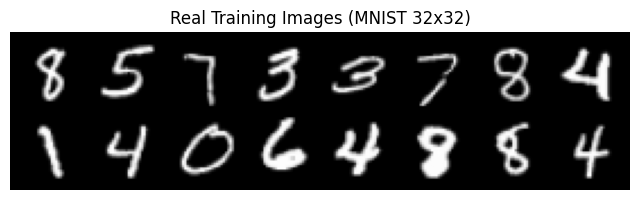

Train: 48,000  |  Val: 12,000  |  Batches/epoch: 375


In [5]:
# Data loading — standard PyTorch torchvision pipeline
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)

# 80 / 20 train-validation split (seeded for reproducibility)
train_size = int(0.8 * len(train_dataset))
val_size   = len(train_dataset) - train_size
train_sub, val_sub = torch.utils.data.random_split(
    train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_sub, batch_size=128, shuffle=True,  num_workers=0, drop_last=True)
val_loader   = DataLoader(val_sub,   batch_size=128, shuffle=False, num_workers=0)
dataloader   = train_loader   # alias kept for any cells that use the old name

# Quick check
real_batch = next(iter(train_loader))
plt.figure(figsize=(8, 3))
plt.axis('off')
plt.title('Real Training Images (MNIST 32x32)')
plt.imshow(
    np.transpose(make_grid(real_batch[0][:16], padding=2, normalize=True).numpy(), (1, 2, 0)),
    cmap='gray'
)
plt.show()
print(f'Train: {len(train_sub):,}  |  Val: {len(val_sub):,}  |  Batches/epoch: {len(train_loader)}')

---
## 2. Minimax Loss Implementation

The GAN objective decomposes into two **Binary Cross-Entropy (BCE)** loss terms that are minimised alternately:

**Discriminator loss** (maximise correct labelling):
$$\mathcal{L}_D = \underbrace{\text{BCE}(D(\mathbf{x}),\, \mathbf{1})}_{\text{real}} + \underbrace{\text{BCE}(D(G(\mathbf{z})),\, \mathbf{0})}_{\text{fake}}$$

**Generator loss** (non-saturating form — maximise $\log D(G(\mathbf{z}))$):
$$\mathcal{L}_G = \text{BCE}(D(G(\mathbf{z})),\, \mathbf{1})$$

Training alternates step-by-step: gradients are blocked from flowing into $G$ during $D$'s update via `.detach()`.

In [6]:
# GAN Training
import time
GAN_EPOCHS = 10
LR         = 0.0002
BETA1      = 0.5
REAL_LABEL = 1.0
FAKE_LABEL = 0.0

criterion  = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

fixed_noise     = torch.randn(16, NZ, 1, 1, device=device)
G_losses, D_losses, img_list = [], [], []
gan_batch_times = []   # collected for Section 6

print('Starting GAN Training...')
print(f'{"Epoch":>7}  {"D_loss":>7}  {"G_loss":>7}  '
      f'{"Train_D_acc":>12}  {"Train_G_fool":>13}  {"Val_D_acc":>10}')
print('-' * 70)

for epoch in range(GAN_EPOCHS):

    # ── Training pass ──────────────────────────────────────────────────────────────────────
    netD.train(); netG.train()
    d_correct = d_total = g_fool = 0

    for real_imgs, _ in train_loader:
        _t0       = time.perf_counter()              # ← batch timer
        B         = real_imgs.size(0)
        real_imgs = real_imgs.to(device)

        # Step 1 — Discriminator update
        netD.zero_grad()
        out_real   = netD(real_imgs)                 # D(x_real)
        lossD_real = criterion(out_real, torch.full((B,), REAL_LABEL, device=device))
        lossD_real.backward()

        noise      = torch.randn(B, NZ, 1, 1, device=device)
        fakes      = netG(noise)
        out_fake_D = netD(fakes.detach())            # D(G(z)) for D update
        lossD_fake = criterion(out_fake_D, torch.full((B,), FAKE_LABEL, device=device))
        lossD_fake.backward()
        lossD = lossD_real + lossD_fake
        optimizerD.step()

        # Step 2 — Generator update
        netG.zero_grad()
        out_fake_G = netD(fakes)                     # D(G(z)) for G update
        lossG      = criterion(out_fake_G, torch.full((B,), REAL_LABEL, device=device))
        lossG.backward()
        optimizerG.step()

        G_losses.append(lossG.item())
        D_losses.append(lossD.item())

        # Accuracy — use already-computed outputs (no extra forward passes)
        with torch.no_grad():
            d_correct += ((out_real.detach()   > 0.5).sum() +
                          (out_fake_D.detach() < 0.5).sum()).item()
            g_fool    += (out_fake_G.detach()  > 0.5).sum().item()
            d_total   += 2 * B

        gan_batch_times.append(time.perf_counter() - _t0)

    train_D_acc  = 100 * d_correct / d_total
    train_G_fool = 100 * g_fool    / (d_total // 2)

    # ── Validation pass (no weight updates) ──────────────────────────────────────────────────
    netD.eval(); netG.eval()
    val_correct = val_total = 0
    with torch.no_grad():
        for real_imgs, _ in val_loader:
            B         = real_imgs.size(0)
            real_imgs = real_imgs.to(device)
            fakes     = netG(torch.randn(B, NZ, 1, 1, device=device))
            val_correct += ((netD(real_imgs) > 0.5).sum() +
                            (netD(fakes)     < 0.5).sum()).item()
            val_total   += 2 * B
    val_D_acc = 100 * val_correct / val_total

    img_list.append(make_grid(netG(fixed_noise).cpu(), padding=2, normalize=True))

    print(f'[{epoch+1:>2}/{GAN_EPOCHS}]  '
          f'{lossD.item():>7.4f}  {lossG.item():>7.4f}  '
          f'{train_D_acc:>11.1f}%  {train_G_fool:>12.1f}%  {val_D_acc:>9.1f}%')

print('GAN Training complete.')

# ── Metrics for Section 6 (collected during training, reused later) ────────────────────
gan_step_ms      = sum(gan_batch_times) / len(gan_batch_times) * 1e3
gan_G_params     = sum(p.numel() for p in netG.parameters())
gan_D_params     = sum(p.numel() for p in netD.parameters())
gan_total_params = gan_G_params + gan_D_params

netG.eval()
_lat = torch.randn(16, NZ, 1, 1, device=device)
with torch.no_grad():
    _t = time.perf_counter()
    for _ in range(5): netG(_lat)
    gan_sample_ms = (time.perf_counter() - _t) / 5 * 1e3

print(f'\nGAN metrics: {gan_total_params:,} params | '
      f'step {gan_step_ms:.1f} ms | sample(16) {gan_sample_ms:.2f} ms')


Starting GAN Training...
  Epoch   D_loss   G_loss   Train_D_acc   Train_G_fool   Val_D_acc
----------------------------------------------------------------------
[ 1/10]   0.1943   2.5787         95.3%           1.9%       47.2%
[ 2/10]   0.2709   2.5623         92.5%           5.1%       59.9%
[ 3/10]   0.3254   2.2161         91.8%           6.1%       56.6%
[ 4/10]   0.4319   2.1757         90.1%           7.0%       50.4%
[ 5/10]   0.3692   2.1113         91.8%           6.3%       76.4%
[ 6/10]   0.5507   2.5102         93.0%           5.1%       76.6%
[ 7/10]   0.2332   2.5906         93.7%           4.3%       78.2%
[ 8/10]   0.1627   4.0875         93.2%           4.5%       57.1%
[ 9/10]   0.0825   4.0282         93.2%           4.0%       70.1%
[10/10]   0.3625   2.5300         95.3%           3.1%       50.0%
GAN Training complete.

GAN metrics: 1,728,128 params | step 13.5 ms | sample(16) 0.26 ms


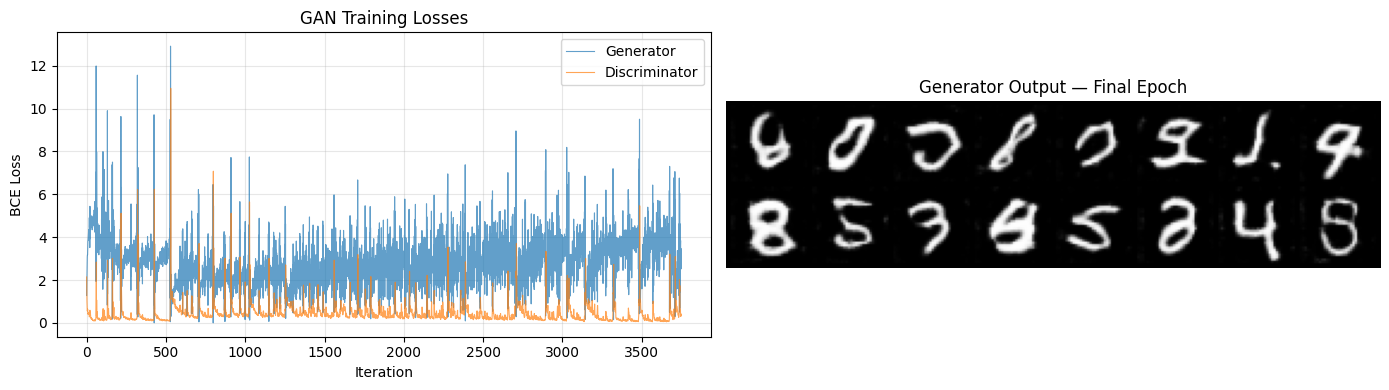

In [7]:
# Visualise training curves and final generated samples
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
axes[0].plot(G_losses, label='Generator',     alpha=0.7, linewidth=0.8)
axes[0].plot(D_losses, label='Discriminator', alpha=0.7, linewidth=0.8)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('GAN Training Losses')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Generated images from fixed noise (final epoch)
axes[1].axis('off')
axes[1].set_title('Generator Output — Final Epoch')
axes[1].imshow(np.transpose(img_list[-1].numpy(), (1, 2, 0)), cmap='gray')

plt.tight_layout()
plt.show()

**Figure 1: GAN Training Losses.**

**Figure 2: Generator Output (Final Epoch).**
A grid of images produced entirely from random noise vectors at the end of training. None of these are real MNIST digits; they are the Generator's learned approximation of the data distribution. Blurry or incoherent images indicate the GAN has not fully converged.

---
## 3. Forward Diffusion Process

Diffusion models learn to generate images by reversing a **gradual noising process** — no adversary required.

![Diffusion overview](https://huggingface.co/blog/assets/78_annotated-diffusion/diffusion_figure.png)

Two coupled processes:

| Process | Symbol | Description |
|---------|---------|-------------|
| **Forward** | $q$ | Add Gaussian noise step-by-step until $\mathbf{x}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ |
| **Reverse** | $p_\theta$ | Trained network denoises step-by-step to recover $\mathbf{x}_0$ |

### The Forward Process: Noise Schedule and Closed-Form Sampling

At each step $t$, a small amount of Gaussian noise is added:

$$q(\mathbf{x}_t \mid \mathbf{x}_{t-1}) = \mathcal{N}\!\left(\mathbf{x}_t;\; \sqrt{1-\beta_t}\,\mathbf{x}_{t-1},\; \beta_t \mathbf{I}\right)$$

where $\{\beta_t\}_{t=1}^T$ is a **linear variance schedule** ($\beta_1 \approx 10^{-4} \to \beta_T \approx 0.02$).

**Closed-form sampling** — skip directly to any step $t$ in one shot:

$$q(\mathbf{x}_t \mid \mathbf{x}_0) = \mathcal{N}\!\left(\mathbf{x}_t;\; \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0,\; (1-\bar{\alpha}_t)\mathbf{I}\right)$$

$$\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$

where $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$. This **reparameterisation** means we can corrupt any image to any noise level in a **single step** — crucial for efficient training.

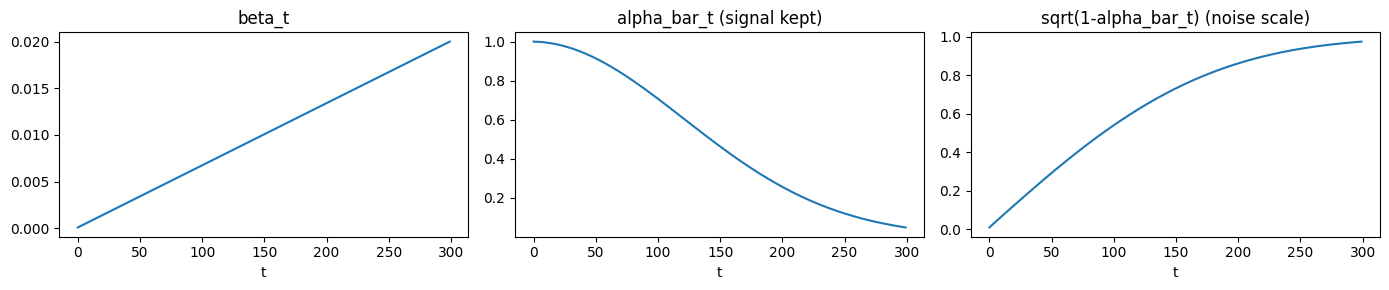

In [8]:
# Noise schedule and derived constants

T        = 300    # Total diffusion timesteps
IMG_SIZE = 32     # Spatial resolution

def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    """
    Linear variance schedule from DDPM (see References).
    Returns T evenly-spaced betas from beta_start to beta_end.
    """
    return torch.linspace(beta_start, beta_end, timesteps)

betas    = linear_beta_schedule(T).to(device)       # beta_t
alphas   = 1.0 - betas                               # alpha_t = 1 - beta_t
alphas_cumprod      = torch.cumprod(alphas, dim=0)   # alpha_bar_t = prod_{s<=t} alpha_s
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)  # alpha_bar_{t-1}

# Useful precomputed constants
sqrt_alphas_cumprod           = alphas_cumprod.sqrt()          # sqrt(alpha_bar_t)
sqrt_one_minus_alphas_cumprod = (1.0 - alphas_cumprod).sqrt()  # sqrt(1 - alpha_bar_t)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

# ── Visualise the schedule ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].plot(betas.cpu());                     axes[0].set_title('beta_t'); axes[0].set_xlabel('t')
axes[1].plot(alphas_cumprod.cpu());            axes[1].set_title('alpha_bar_t (signal kept)'); axes[1].set_xlabel('t')
axes[2].plot(sqrt_one_minus_alphas_cumprod.cpu()); axes[2].set_title('sqrt(1-alpha_bar_t) (noise scale)'); axes[2].set_xlabel('t')
plt.tight_layout(); plt.show()

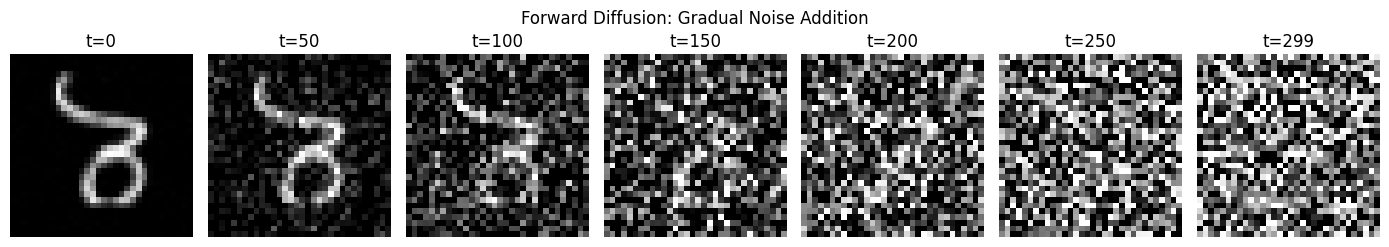

In [9]:
def q_sample(x0, t, noise=None):
    """
    Forward diffusion: corrupt x0 to x_t in ONE closed-form step.
    x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * epsilon

    Closed-form forward diffusion step (see References).

    Args:
        x0:    Clean images (B, C, H, W)
        t:     Timestep indices (B,)
        noise: Optional pre-sampled epsilon; defaults to N(0, I)
    """
    if noise is None:
        noise = torch.randn_like(x0)  # epsilon ~ N(0, I)

    # Index the schedule tensors by t; reshape to (B, 1, 1, 1) for broadcasting
    sqrt_ab    = sqrt_alphas_cumprod[t].reshape(-1, 1, 1, 1)
    sqrt_1mab  = sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1, 1, 1)

    return sqrt_ab * x0 + sqrt_1mab * noise  # Reparameterisation trick

# ── Visualise the forward noising process ────────────────────────────────
sample_img = next(iter(dataloader))[0][0].unsqueeze(0).to(device)
timesteps_to_show = [0, 50, 100, 150, 200, 250, 299]

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(14, 2.5))
for ax, tv in zip(axes, timesteps_to_show):
    t_tensor = torch.tensor([tv], device=device)
    noisy    = q_sample(sample_img, t_tensor)
    ax.imshow(noisy.squeeze().cpu().clamp(-1, 1) * 0.5 + 0.5, cmap='gray')
    ax.set_title(f't={tv}'); ax.axis('off')
plt.suptitle('Forward Diffusion: Gradual Noise Addition', fontsize=12)
plt.tight_layout(); plt.show()

---
## 4. Reverse Diffusion with U-Net

### The Problem: Undoing Noise

In Section 3 we built the **forward process**: given a clean image $x_0$, we can corrupt it
to a noisy image $x_t$ in one closed-form step using `q_sample`.

Now we want to go the **other direction** — start from pure noise $x_T \sim \mathcal{N}(0, I)$
and gradually denoise it back to a realistic image:

$$x_T \xrightarrow{\text{denoise}} x_{T-1} \xrightarrow{\text{denoise}} \cdots \xrightarrow{\text{denoise}} x_0$$

Each arrow is one reverse step. We need a neural network to learn what each step looks like.

### What the Network Learns

The reverse step from $x_t$ to $x_{t-1}$ is modelled as a Gaussian:

$$p_\theta(x_{t-1} \mid x_t) = \mathcal{N}(x_{t-1};\; \mu_\theta(x_t, t),\; \sigma_t^2 I)$$

**Plain English:** *Given the noisy image at step $t$, the slightly less-noisy image at step
$t{-}1$ follows a Gaussian whose mean $\mu_\theta$ is predicted by a neural network.*

The network takes two inputs: the noisy image $x_t$ and the timestep $t$ (so it knows how much noise to expect at this stage of denoising).

### Key Insight: Predict the Noise, Not the Image

The key insight (see References): instead of predicting the mean $\mu_\theta$ directly,
train the network $\epsilon_\theta$ to **predict the noise $\epsilon$ that was added** to $x_0$.

> **Why?** Recall from Section 3: $x_t = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\epsilon$.
> If the network can predict $\epsilon$, we can algebraically solve for $x_0$ and then compute $x_{t-1}$.

The training loss becomes a simple MSE between the **true noise** $\epsilon$ and the **predicted noise** $\epsilon_\theta$:

$$\mathcal{L}_{\text{simple}} = \mathbb{E}_{t,\,x_0,\,\epsilon}\!\left[\|\epsilon - \epsilon_\theta(\underbrace{\sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\epsilon}_{x_t},\, t)\|^2\right]$$

| Symbol | Meaning |
|---|---|
| $\epsilon \sim \mathcal{N}(0,I)$ | The actual noise that was added (sampled randomly) |
| $x_t$ (underbraced) | The noisy image fed to the network — same formula as `q_sample` |
| $\epsilon_\theta(x_t, t)$ | The network's predicted noise |
| $\|\cdot\|^2$ | MSE — just like any standard regression loss |

This is simply **predicting which noise was added** — a standard regression problem.

### U-Net Architecture

![U-Net](https://i.imgur.com/jeDVpqF.png)

*Source: Ronneberger et al. 2015 (via milesial/Pytorch-UNet) — U-Net encoder-decoder with skip connections.*

The U-shape gives the architecture its name. Reading the diagram left-to-right:

| Diagram region | What it does | Code class |
|---|---|---|
| **Left side (going down)** | Encoder — progressively halves spatial size, doubles channels | `Down` |
| **Blue double-arrow boxes** | Two conv layers + residual skip; repeated at every level | `ResidualBlock` |
| **Grey horizontal arrows** | Skip connections — copy encoder features to the matching decoder level | `skip1`, `skip2` in `UNet.forward` |
| **Bottom** | Bottleneck — deepest features, smallest spatial size | `bottleneck` in `UNet` |
| **Right side (going up)** | Decoder — progressively doubles spatial size, concatenates skips | `Up` |
| **Final conv** | Maps decoder features → noise prediction (same size as input) | `out_conv` |

**Why U-Net for DDPM?**
1. The **encoder** compresses the noisy image into global context.
2. The **decoder** restores fine spatial detail with help from the skip connections.
3. The timestep $t$ is injected at every `ResidualBlock` via a sinusoidal embedding — the diagram does not show this; it is the key DDPM addition over the original U-Net.

### Timestep Embedding


In [10]:
# Sinusoidal Timestep Embedding
# Same formula as Transformer positional encoding (Vaswani et al., 2017)

class SinusoidalPositionEmbeddings(nn.Module):
    """
    Encodes scalar timestep t as a fixed-dimension sinusoidal vector.
    Allows the U-Net to condition its denoising on 'how noisy' the image is.

    PE(t, 2i)   = sin(t / 10000^(2i/d))
    PE(t, 2i+1) = cos(t / 10000^(2i/d))
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):  # t: (B,)
        half   = self.dim // 2
        freqs  = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
        )                              # (half,)
        args   = t[:, None].float() * freqs[None, :]  # (B, half)
        return torch.cat([args.sin(), args.cos()], dim=-1)  # (B, dim)

In [11]:
# U-Net building blocks
# Each class below corresponds to a labelled region of the U-Net diagram above.

# ─────────────────────────────────────────────────────────────────────────────
# DIAGRAM: BLUE DOUBLE-ARROW BOXES — appears at every level, encoder and decoder
# Two 3×3 conv layers with a residual skip; timestep t injected between them.
# GroupNorm (not BatchNorm) — stable at the small per-level feature-map sizes.
# ─────────────────────────────────────────────────────────────────────────────
class ResidualBlock(nn.Module):
    """
    Residual block with timestep conditioning.
    The timestep embedding is projected via a Linear layer and *added* to
    intermediate feature maps, letting the network adapt to each noise level.
    Uses GroupNorm (stable at small batch sizes) and SiLU (smooth activation).
    """
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.GroupNorm(8, in_ch),   # Normalise over groups of 8 channels
            nn.SiLU(),                # Swish / SiLU — smoother than ReLU
            nn.Conv2d(in_ch, out_ch, 3, padding=1)
        )
        # Project time embedding → same channel count as feature maps
        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_ch))
        self.conv2 = nn.Sequential(
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1)
        )
        # 1×1 conv for skip if channel dimensions differ
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        # Add time embedding — reshape (B, C) → (B, C, 1, 1) to broadcast spatially
        h = h + self.time_proj(t_emb)[:, :, None, None]
        h = self.conv2(h)
        return h + self.skip(x)  # Residual connection


# ─────────────────────────────────────────────────────────────────────────────
# DIAGRAM: LEFT SIDE going DOWN — encoder path
# ResidualBlock extracts features at the current resolution, then a strided conv
# halves the spatial size (2× downsampling).  Before downsampling, the
# full-resolution output is saved as `skip` — the grey horizontal arrows in the
# diagram that carry fine detail to the matching decoder level on the right.
# ─────────────────────────────────────────────────────────────────────────────
class Down(nn.Module):
    """Encoder block: ResidualBlock then 2× spatial downsampling via strided conv."""
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.res   = ResidualBlock(in_ch, out_ch, time_emb_dim)
        self.pool  = nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1)

    def forward(self, x, t_emb):
        x    = self.res(x, t_emb)   # Apply residual block
        skip = x                    # Save full-resolution features for skip
        return self.pool(x), skip   # Return downsampled + skip-connection tensor


# ─────────────────────────────────────────────────────────────────────────────
# DIAGRAM: RIGHT SIDE going UP — decoder path
# Bilinear upsample doubles the spatial size, then the matching encoder skip
# (grey arrows arriving from the left) is concatenated channel-wise, then a
# ResidualBlock refines. The skip gives the decoder fine spatial information
# that was compressed away during encoding.
# ─────────────────────────────────────────────────────────────────────────────
class Up(nn.Module):
    """Decoder block: 2× bilinear upsample, concatenate skip, then ResidualBlock."""
    def __init__(self, in_ch, skip_ch, out_ch, time_emb_dim):
        super().__init__()
        self.up  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        # After concat: total channels = in_ch (upsampled) + skip_ch
        self.res = ResidualBlock(in_ch + skip_ch, out_ch, time_emb_dim)

    def forward(self, x, skip, t_emb):
        x = self.up(x)                    # (B, in_ch, 2H, 2W)
        x = torch.cat([x, skip], dim=1)  # (B, in_ch+skip_ch, 2H, 2W)
        return self.res(x, t_emb)         # (B, out_ch, 2H, 2W)


In [12]:
class UNet(nn.Module):
    """
    Simplified U-Net for DDPM noise prediction.
    Input:  noisy image x_t (B, 1, 32, 32) + timestep t (B,)
    Output: predicted noise epsilon (B, 1, 32, 32)

    Channel trace (base_dim=32):
      init_conv : 1  → 32   @32×32
      down1 res : 32 → 64   @32×32  →  pool → 64@16×16   skip1=64@32×32
      down2 res : 64 → 128  @16×16  →  pool → 128@8×8    skip2=128@16×16
      bottleneck: 128 → 128 @8×8
      up1       : up→128@16×16  cat(skip2=128) → 256@16×16  res→64@16×16
      up2       : up→64@32×32   cat(skip1=64)  → 128@32×32  res→32@32×32
      out_conv  : 32 → 1  @32×32

    Architecture from the DDPM paper (see References).
    """
    def __init__(self, img_ch=1, base=32, t_dim=128):
        super().__init__()
        # Not shown in diagram — MLP encodes scalar t into a vector added at every ResidualBlock
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(base),
            nn.Linear(base, t_dim), nn.SiLU(), nn.Linear(t_dim, t_dim)
        )
        # Diagram: entry conv — maps raw image (1 ch) to feature space (32 ch), stays at 32×32
        self.init_conv  = nn.Conv2d(img_ch, base, 3, padding=1)
        # Diagram: ENCODER — left side going down; each Down halves spatial size
        self.down1      = Down(base,     base * 2, t_dim)   # 32→16
        self.down2      = Down(base * 2, base * 4, t_dim)   # 16→8
        # Diagram: BOTTLENECK — bottom of the U; deepest, smallest spatial size (8×8)
        self.bottleneck = ResidualBlock(base * 4, base * 4, t_dim)
        # Diagram: DECODER — right side going up; each Up doubles spatial size + concatenates skip
        self.up1        = Up(base * 4, base * 4, base * 2, t_dim)  # 8→16
        self.up2        = Up(base * 2, base * 2, base,     t_dim)  # 16→32
        # Diagram: output conv — maps decoder features back to 1-channel noise prediction
        self.out_conv   = nn.Sequential(
            nn.GroupNorm(8, base), nn.SiLU(),
            nn.Conv2d(base, img_ch, 1)
        )

    def forward(self, x, t):
        t_emb          = self.time_mlp(t)
        # ── Entry ────────────────────────────────────────────────────────
        x              = self.init_conv(x)              # (B, 32, 32, 32)
        # ── Encoder: going DOWN the left side of the U ───────────────────
        x, skip1       = self.down1(x, t_emb)           # x=(B,64,16,16) skip1=(B,64,32,32)
        x, skip2       = self.down2(x, t_emb)           # x=(B,128,8,8)  skip2=(B,128,16,16)
        # ── Bottleneck: bottom of the U ───────────────────────────────────
        x              = self.bottleneck(x, t_emb)      # (B, 128, 8, 8)
        # ── Decoder: going UP the right side; skips arrive from matching encoder level ──
        x              = self.up1(x, skip2, t_emb)      # skip2 from down2  → (B, 64, 16, 16)
        x              = self.up2(x, skip1, t_emb)      # skip1 from down1  → (B, 32, 32, 32)
        # ── Output ───────────────────────────────────────────────────────
        return self.out_conv(x)                          # (B, 1, 32, 32)

unet = UNet().to(device)
print(f'U-Net parameters: {sum(p.numel() for p in unet.parameters()):,}')

# Verify shapes
dummy_x = torch.randn(4, 1, 32, 32, device=device)
dummy_t = torch.randint(0, T, (4,), device=device)
print(f'Input: {dummy_x.shape}  →  Output: {unet(dummy_x, dummy_t).shape}')


U-Net parameters: 1,238,369
Input: torch.Size([4, 1, 32, 32])  →  Output: torch.Size([4, 1, 32, 32])


### Training the U-Net (Algorithm 1)

1. Sample $\mathbf{x}_0 \sim q(\mathbf{x}_0)$ — a real image.
2. Sample $t \sim \text{Uniform}(1, T)$ — a random noise level.
3. Sample $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ — the noise to predict.
4. Corrupt the image: $\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}$
5. Predict noise: $\hat{\boldsymbol{\epsilon}} = \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$
6. Minimise: $\|\boldsymbol{\epsilon} - \hat{\boldsymbol{\epsilon}}\|^2$

This is equivalent to **denoising score matching** — the U-Net learns the score function $\nabla_{\mathbf{x}} \log p(\mathbf{x})$ at each noise level.

In [13]:
# ── train_ddpm: reusable function used here AND in Exercise 1 ─────────────────
def train_ddpm(model, train_loader, val_loader, epochs, optimizer, q_fn=None):
    '''
    Train a DDPM U-Net for noise prediction.
    q_fn: forward-diffusion function (defaults to the linear-schedule q_sample).
    Returns dict with train_loss, val_loss, and step_ms lists (one per epoch).
    '''
    if q_fn is None:
        q_fn = q_sample
    history = {'train_loss': [], 'val_loss': [], 'step_ms': []}

    for epoch in range(epochs):
        # Training
        model.train()
        tr_losses, batch_times = [], []
        for imgs, _ in train_loader:
            _t0   = time.perf_counter()
            imgs  = imgs.to(device)
            t     = torch.randint(0, T, (imgs.size(0),), device=device).long()
            noise = torch.randn_like(imgs)
            loss  = F.mse_loss(model(q_fn(imgs, t, noise), t), noise)
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_losses.append(loss.item())
            batch_times.append(time.perf_counter() - _t0)

        # Validation (no gradient)
        model.eval()
        vl_losses = []
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs  = imgs.to(device)
                t     = torch.randint(0, T, (imgs.size(0),), device=device).long()
                noise = torch.randn_like(imgs)
                vl_losses.append(F.mse_loss(model(q_fn(imgs, t, noise), t), noise).item())

        tr = sum(tr_losses) / len(tr_losses)
        vl = sum(vl_losses) / len(vl_losses)
        history['train_loss'].append(tr)
        history['val_loss'].append(vl)
        history['step_ms'].append(sum(batch_times) / len(batch_times) * 1e3)
        print(f'Epoch [{epoch+1:>2}/{epochs}] | Train MSE: {tr:.5f} | Val MSE: {vl:.5f}')

    return history


# ── Train the DDPM U-Net ────────────────────────────────────────────────────────────────────────
ddpm_opt     = optim.Adam(unet.parameters(), lr=2e-4)
DDPM_EPOCHS  = 10
print('Starting DDPM Training...')
ddpm_history = train_ddpm(unet, train_loader, val_loader, DDPM_EPOCHS, ddpm_opt)
ddpm_losses  = ddpm_history['train_loss']   # alias — used by Section 6 plots

# ── Metrics for Section 6 ──────────────────────────────────────────────────────────────────
ddpm_step_ms = sum(ddpm_history['step_ms']) / len(ddpm_history['step_ms'])
ddpm_params  = sum(p.numel() for p in unet.parameters())
print(f'\nDDPM metrics: {ddpm_params:,} params | step {ddpm_step_ms:.1f} ms')


Starting DDPM Training...
Epoch [ 1/10] | Train MSE: 0.08044 | Val MSE: 0.04644
Epoch [ 2/10] | Train MSE: 0.04429 | Val MSE: 0.04188
Epoch [ 3/10] | Train MSE: 0.04006 | Val MSE: 0.03830
Epoch [ 4/10] | Train MSE: 0.03725 | Val MSE: 0.03588
Epoch [ 5/10] | Train MSE: 0.03559 | Val MSE: 0.03535
Epoch [ 6/10] | Train MSE: 0.03459 | Val MSE: 0.03353
Epoch [ 7/10] | Train MSE: 0.03310 | Val MSE: 0.03329
Epoch [ 8/10] | Train MSE: 0.03299 | Val MSE: 0.03269
Epoch [ 9/10] | Train MSE: 0.03236 | Val MSE: 0.03215
Epoch [10/10] | Train MSE: 0.03165 | Val MSE: 0.03135

DDPM metrics: 1,238,369 params | step 58.2 ms


### Reverse Sampling (Algorithm 2)

Start from $\mathbf{x}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and iterate for $t = T, T-1, \ldots, 1$:

$$\mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)\right) + \sigma_t \mathbf{z}, \quad \mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$

where $\sigma_t = \sqrt{\tilde{\beta}_t}$ and $\mathbf{z} = \mathbf{0}$ when $t = 1$.

DDPM sample(16): 880 ms


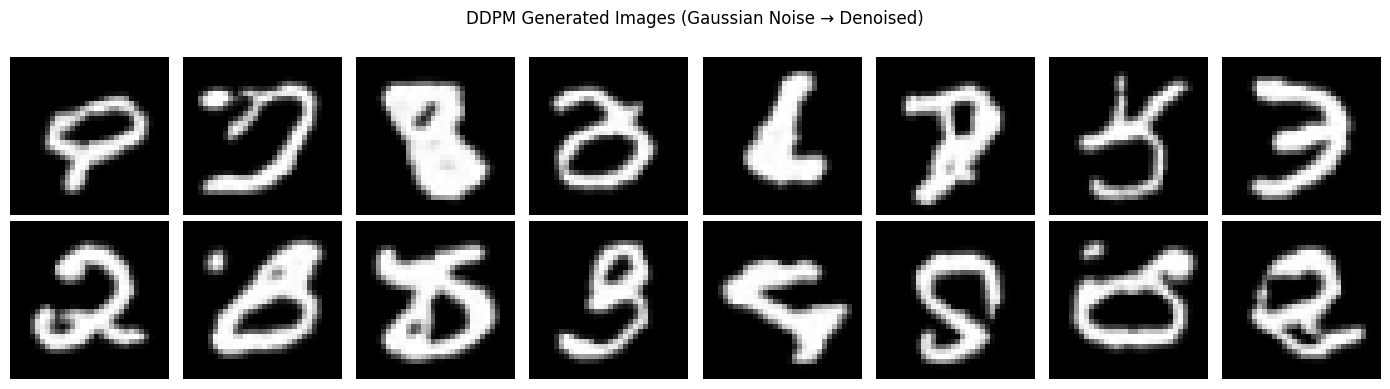

In [14]:
@torch.no_grad()
def p_sample(model, x_t, t_val):
    '''One reverse-diffusion step: x_t -> x_{t-1} (Algorithm 2, see References).'''
    t_batch  = torch.full((x_t.size(0),), t_val, device=device, dtype=torch.long)
    eps_pred = model(x_t, t_batch)                          # Predicted noise

    coeff = betas[t_val] / sqrt_one_minus_alphas_cumprod[t_val]
    mean  = (1.0 / alphas[t_val].sqrt()) * (x_t - coeff * eps_pred)

    if t_val == 0:
        return mean
    return mean + posterior_variance[t_val].sqrt() * torch.randn_like(x_t)

@torch.no_grad()
def p_sample_loop(model, shape):
    '''Full reverse process: pure noise -> generated image over T steps.'''
    img = torch.randn(shape, device=device)
    for t_val in reversed(range(T)):
        img = p_sample(model, img, t_val)
    return img

unet.eval()
_t0       = time.perf_counter()
generated = p_sample_loop(unet, (16, 1, 32, 32))
ddpm_sample_ms = (time.perf_counter() - _t0) * 1e3   # ms for 16 images
print(f'DDPM sample(16): {ddpm_sample_ms:.0f} ms')

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i].squeeze().cpu().clamp(-1, 1) * 0.5 + 0.5, cmap='gray')
    ax.axis('off')
plt.suptitle('DDPM Generated Images (Gaussian Noise → Denoised)')
plt.tight_layout(); plt.show()


**Figure: DDPM Generated Images.**
16 images produced by starting from pure Gaussian noise and running 300 reverse-denoising steps. At each step, the U-Net predicts the noise component in the current image, subtracts it, and adds a small controlled amount of noise to avoid collapse. By step 0, the noise has been fully removed and a clean digit emerges. Unlike the GAN, there is no adversarial training; the U-Net is trained purely by regression on the noise.

---
## 5. Conditioning Techniques: Classifier-Free Guidance

Classifier-Free Guidance (CFG) enables **class-conditional generation** using only a single model — no external classifier needed.

**Training**: Randomly replace the class label $c$ with a null token $\varnothing$ (probability $p_{\text{uncond}} \approx 0.1$), so the model learns both $p(\mathbf{x}|c)$ and $p(\mathbf{x})$ simultaneously.

**Guided sampling**: Combine conditional and unconditional noise predictions:

$$\tilde{\boldsymbol{\epsilon}}_\theta(\mathbf{x}_t, c) = \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, \varnothing) + w \cdot \underbrace{\left(\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, c) - \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, \varnothing)\right)}_{\text{guidance direction}}$$

| Guidance scale $w$ | Effect |
|--------------------|--------|
| $w = 0$ | Pure unconditional generation |
| $w = 1$ | Standard conditional generation |
| $w > 1$ | Amplified class-specificity (higher quality, lower diversity) |

### Conditional U-Net Architecture

In [15]:
# Conditional U-Net with class embedding

NUM_CLASSES = 10  # MNIST digits 0–9

class ConditionalUNet(nn.Module):
    """
    U-Net conditioned on class label c via a learned embedding table.
    Index NUM_CLASSES acts as the 'null' token (empty conditioning).
    The class embedding is *added* to the timestep embedding so both
    conditions are injected through the same ResidualBlock pathway.
    """
    def __init__(self, img_ch=1, base=32, t_dim=128, num_cls=NUM_CLASSES):
        super().__init__()
        self.time_mlp  = nn.Sequential(
            SinusoidalPositionEmbeddings(base),
            nn.Linear(base, t_dim), nn.SiLU(), nn.Linear(t_dim, t_dim)
        )
        # Embedding table: rows 0..num_cls-1 = class tokens, row num_cls = null token
        self.class_emb = nn.Embedding(num_cls + 1, t_dim)

        self.init_conv  = nn.Conv2d(img_ch, base, 3, padding=1)
        self.down1      = Down(base,     base * 2, t_dim)
        self.down2      = Down(base * 2, base * 4, t_dim)
        self.bottleneck = ResidualBlock(base * 4, base * 4, t_dim)
        self.up1        = Up(base * 4, base * 4, base * 2, t_dim)
        self.up2        = Up(base * 2, base * 2, base,     t_dim)
        self.out_conv   = nn.Sequential(
            nn.GroupNorm(8, base), nn.SiLU(), nn.Conv2d(base, img_ch, 1)
        )

    def forward(self, x, t, c=None):
        """
        Args:
            x: Noisy image (B, 1, H, W)
            t: Timesteps   (B,)
            c: Class labels (B,); pass None to use unconditional null embedding
        """
        t_emb = self.time_mlp(t)

        # If no label provided, use null token (index = NUM_CLASSES)
        if c is None:
            c = torch.full((x.size(0),), NUM_CLASSES, device=x.device, dtype=torch.long)
        cond  = t_emb + self.class_emb(c)   # Additive conditioning

        x          = self.init_conv(x)
        x, skip1   = self.down1(x, cond)
        x, skip2   = self.down2(x, cond)
        x          = self.bottleneck(x, cond)
        x          = self.up1(x, skip2, cond)
        x          = self.up2(x, skip1, cond)
        return self.out_conv(x)

cfg_model = ConditionalUNet().to(device)
print(f'Conditional U-Net parameters: {sum(p.numel() for p in cfg_model.parameters()):,}')

Conditional U-Net parameters: 1,239,777


In [16]:
# CFG Training: randomly drop class labels to enable guidance at inference

P_UNCOND    = 0.10   # 10% chance of dropping the label (replacing with null token)
CFG_EPOCHS  = 5
cfg_opt     = optim.Adam(cfg_model.parameters(), lr=2e-4)
cfg_losses  = []

print('Starting CFG Training...')
for epoch in range(CFG_EPOCHS):
    epoch_losses = []
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        B     = imgs.size(0)
        t     = torch.randint(0, T, (B,), device=device).long()
        noise = torch.randn_like(imgs)
        x_t   = q_sample(imgs, t, noise=noise)

        # ── Classifier-Free label dropout ────────────────────────────────
        # With probability P_UNCOND, replace the class label with the null token
        drop_mask = (torch.rand(B, device=device) < P_UNCOND)
        labels_dropped = labels.clone()
        labels_dropped[drop_mask] = NUM_CLASSES   # null token index

        # Forward: model sees a mix of labelled and unlabelled examples per batch
        pred  = cfg_model(x_t, t, c=labels_dropped)
        loss  = F.mse_loss(pred, noise)

        cfg_opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cfg_model.parameters(), 1.0)
        cfg_opt.step()

        epoch_losses.append(loss.item())

    avg = sum(epoch_losses) / len(epoch_losses)
    cfg_losses.append(avg)
    print(f'Epoch [{epoch+1}/{CFG_EPOCHS}] | CFG MSE Loss: {avg:.5f}')

print('CFG Training complete.')

Starting CFG Training...
Epoch [1/5] | CFG MSE Loss: 0.08846
Epoch [2/5] | CFG MSE Loss: 0.04569
Epoch [3/5] | CFG MSE Loss: 0.04077
Epoch [4/5] | CFG MSE Loss: 0.03769
Epoch [5/5] | CFG MSE Loss: 0.03557
CFG Training complete.


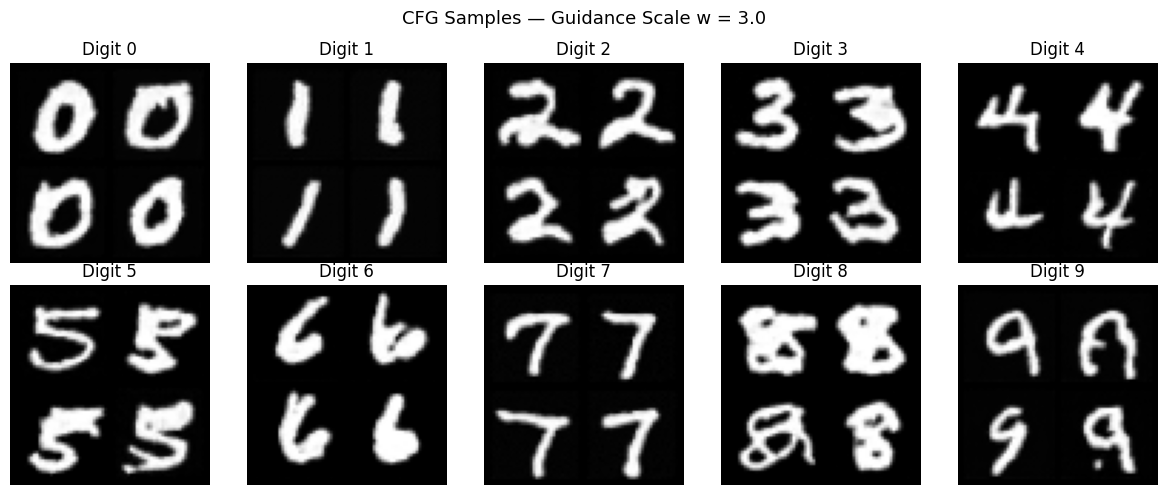

In [17]:
@torch.no_grad()
def cfg_sample(model, shape, cls_label, w=3.0):
    """
    Classifier-Free Guidance sampling.
    Runs the U-Net TWICE per step — once with class label, once with null token —
    then interpolates the two noise predictions with guidance scale w.

    CFG sampling — combines conditional and unconditional noise predictions (see References).

    Args:
        model:     Trained ConditionalUNet
        shape:     Output shape (B, C, H, W)
        cls_label: Integer class index to generate
        w:         Guidance scale (w>1 sharpens class specificity)
    """
    img  = torch.randn(shape, device=device)
    lbls = torch.full((shape[0],), cls_label,   device=device, dtype=torch.long)
    null = torch.full((shape[0],), NUM_CLASSES, device=device, dtype=torch.long)

    for t_val in reversed(range(T)):
        t_batch = torch.full((shape[0],), t_val, device=device, dtype=torch.long)

        # Conditional prediction (with class label)
        eps_cond   = model(img, t_batch, c=lbls)
        # Unconditional prediction (with null token)
        eps_uncond = model(img, t_batch, c=null)

        # Guided noise: push in the conditional direction
        # w=0 → unconditional; w=1 → conditional; w>1 → amplified conditioning
        eps_guided = eps_uncond + w * (eps_cond - eps_uncond)

        # Reverse step using guided noise estimate
        coeff = betas[t_val] / sqrt_one_minus_alphas_cumprod[t_val]
        mean  = (1.0 / alphas[t_val].sqrt()) * (img - coeff * eps_guided)

        if t_val > 0:
            mean = mean + posterior_variance[t_val].sqrt() * torch.randn_like(img)
        img = mean

    return img

# ── Generate one row per digit ─────────────────────────────────────────────
cfg_model.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    ax      = axes[digit // 5][digit % 5]
    samples = cfg_sample(cfg_model, (4, 1, 32, 32), cls_label=digit, w=3.0)
    grid    = make_grid(samples.clamp(-1, 1), nrow=2, normalize=True)
    ax.imshow(np.transpose(grid.cpu().numpy(), (1, 2, 0)), cmap='gray')
    ax.set_title(f'Digit {digit}')
    ax.axis('off')
plt.suptitle('CFG Samples — Guidance Scale w = 3.0', fontsize=13)
plt.tight_layout(); plt.show()

**Figure: CFG Samples (Guidance Scale w = 3.0).**
Ten panels, one per digit (0-9), each showing 4 samples generated with Classifier-Free Guidance. The guidance scale w controls the trade-off between diversity and class specificity: at w=1 the model ignores the class label (unconditional); at w=3 it steers strongly toward the target digit while retaining some variety. Higher w produces sharper, more recognisable digits but with less sample diversity.

---
## 6. Architectural Comparison: GAN vs. Diffusion

| Property | GAN | Diffusion (DDPM) |
|---|---|---|
| **Training objective** | Minimax / adversarial BCE | MSE noise prediction |
| **Training stability** | Unstable — mode collapse, vanishing gradients | Stable — simple regression |
| **Sampling speed** | **Fast** — single forward pass | **Slow** — $T$ reverse steps (100–1000) |
| **Sample quality** | High, but limited diversity | State-of-the-art quality *and* diversity |
| **Mode coverage** | Often misses modes of $p_{\text{data}}$ | Excellent coverage |
| **Conditioning** | Requires architectural changes (cGAN) | Natural via CFG — one model, no extra network |
| **Likelihood** | Not tractable | Tractable lower bound (ELBO) |
| **Key failure mode** | Training instability, mode collapse | Slow iterative sampling |

### Training Dynamics

**GAN (adversarial)**
The Generator and Discriminator play a zero-sum game. If either network dominates early, training can collapse: the Discriminator becomes perfect and the Generator’s gradients vanish, or the Generator learns to produce a single plausible output (*mode collapse*). Careful hyperparameter tuning and architectural choices (DCGAN guidelines) are essential for stability.

**Diffusion (denoising)**
Training is stable because the objective is a straightforward MSE regression — the model simply learns “what noise was added?” at each of $T$ noise levels. There are no competing networks and no min-max instability. The trade-off is **sampling speed**: generating a single image requires $T$ sequential U-Net forward passes (e.g. 300 steps here).

### When to Use Each

| Use GANs when… | Use Diffusion when… |
|---|---|
| Real-time or low-latency generation is required | Sample quality and diversity matter most |
| Paired data is available (pix2pix, image-to-image) | Flexible conditioning (text-to-image, in-painting) |
| Discriminative signal is available | Probabilistic modelling / likelihood estimation needed |


> **Bottom line**: Diffusion models now dominate generative image modelling (Stable Diffusion, DALL-E 3, Imagen) due to superior quality and diversity. GANs remain valuable for applications requiring fast, single-step synthesis.

The cell below uses numbers collected during the training runs above to confirm these claims empirically.


Metric                                           GAN              DDPM
-------------------------------------------------------------------
Parameters (total)                         1,728,128         1,238,369
Model size (MB)                                  6.9               5.0
Training step (ms/batch)                        13.5              58.2
Sampling time (ms, 16 imgs)                     0.26               880
GAN sampling speedup vs DDPM            3432x faster          baseline
Final train loss  (G / MSE)                   3.5162           0.03165
Final D loss / Val MSE                        0.3164           0.03135


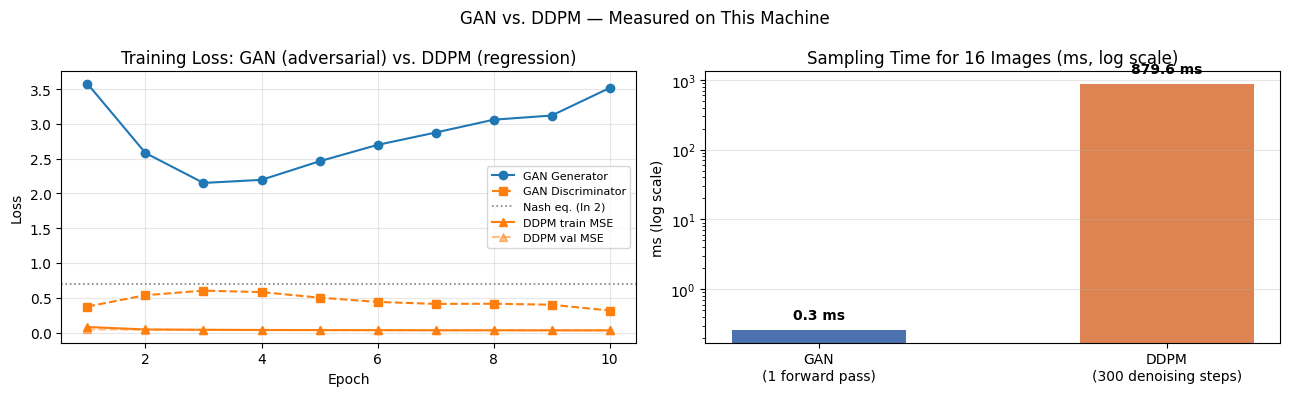

In [18]:
# All metrics were collected during training above
# gan_total_params, gan_step_ms, gan_sample_ms  <- end of Section 2 training cell
# ddpm_params, ddpm_step_ms                     <- end of Section 4 training cell
# ddpm_sample_ms                                <- Section 4 sampling cell
# G_losses, D_losses, ddpm_history              <- training loops

# ── 1. Empirical comparison table ────────────────────────────────────────
iters_per_epoch = len(train_loader)
gan_G_epoch, gan_D_epoch = [], []
for e in range(GAN_EPOCHS):
    s, end = e * iters_per_epoch, (e + 1) * iters_per_epoch
    gan_G_epoch.append(sum(G_losses[s:end]) / len(G_losses[s:end]))
    gan_D_epoch.append(sum(D_losses[s:end]) / len(D_losses[s:end]))

W = 35
rows = [
    ("Metric",                       "GAN",                                      "DDPM"),
    ("-" * 67,                       "",                                         ""),
    ("Parameters (total)",           f"{gan_total_params:,}",                    f"{ddpm_params:,}"),
    ("Model size (MB)",              f"{gan_total_params*4/1e6:.1f}",            f"{ddpm_params*4/1e6:.1f}"),
    ("Training step (ms/batch)",     f"{gan_step_ms:.1f}",                       f"{ddpm_step_ms:.1f}"),
    ("Sampling time (ms, 16 imgs)",  f"{gan_sample_ms:.2f}",                     f"{ddpm_sample_ms:.0f}"),
    ("GAN sampling speedup vs DDPM", f"{ddpm_sample_ms/gan_sample_ms:.0f}x faster",  "baseline"),
    ("Final train loss  (G / MSE)",  f"{gan_G_epoch[-1]:.4f}",                   f"{ddpm_history['train_loss'][-1]:.5f}"),
    ("Final D loss / Val MSE",       f"{gan_D_epoch[-1]:.4f}",                   f"{ddpm_history['val_loss'][-1]:.5f}"),
]
for label, gan_val, ddpm_val in rows:
    if label.startswith("-"):
        print(label)
    else:
        print(f"{label:<{W}} {gan_val:>16}  {ddpm_val:>16}")

# ── 2. Loss curves + sampling speed bar chart ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss curves — GAN oscillates, DDPM decreases monotonically
ax = axes[0]
ax.plot(range(1, GAN_EPOCHS + 1), gan_G_epoch, "o-",  label="GAN Generator")
ax.plot(range(1, GAN_EPOCHS + 1), gan_D_epoch, "s--", label="GAN Discriminator")
ax.axhline(0.693, color="gray", ls=":", lw=1.2, label="Nash eq. (ln 2)")
ax.plot(range(1, DDPM_EPOCHS + 1), ddpm_history["train_loss"], "^-",
        color="tab:orange", label="DDPM train MSE")
ax.plot(range(1, DDPM_EPOCHS + 1), ddpm_history["val_loss"], "^--",
        color="tab:orange", alpha=0.5, label="DDPM val MSE")
ax.set_title("Training Loss: GAN (adversarial) vs. DDPM (regression)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Sampling speed — log scale to show the gap clearly
ax2 = axes[1]
bars = ax2.bar(
    ["GAN\n(1 forward pass)", "DDPM\n(" + str(T) + " denoising steps)"],
    [gan_sample_ms, ddpm_sample_ms],
    color=["#4C72B0", "#DD8452"], width=0.5
)
ax2.set_yscale("log")
ax2.set_title("Sampling Time for 16 Images (ms, log scale)")
ax2.set_ylabel("ms (log scale)")
for bar, v in zip(bars, [gan_sample_ms, ddpm_sample_ms]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.3,
             f"{v:.1f} ms", ha="center", va="bottom", fontweight="bold")
ax2.grid(True, axis="y", alpha=0.3)

plt.suptitle("GAN vs. DDPM — Measured on This Machine", fontsize=12)
plt.tight_layout(); plt.show()


**Figure 1: Training Loss Comparison.**

**Figure 2: Sampling Speed (log scale).**
The GAN generates 16 images in a single forward pass (milliseconds). DDPM requires 300 sequential denoising steps, making it orders of magnitude slower at inference. The log scale is needed to make both bars visible given the large difference in magnitude.

---
# Exercises

### Exercise 1: Cosine Beta Schedule

In **Section 4** we trained a `UNet` using the **linear** beta schedule — $\beta_t$ increases
uniformly from $10^{-4}$ to $0.02$ over $T = 300$ steps.
A side effect is that $\bar{\alpha}_t$ (the signal fraction remaining) drops steeply and the
image is nearly pure noise by step ~150.

Nichol & Dhariwal (2021) proposed a **cosine** schedule that keeps $\bar{\alpha}_t$ near 1
for roughly the first third of the schedule — so the `UNet` gets to practice denoising
almost-clean images for longer before confronting heavy noise.
This smooths out the learning signal and tends to improve final sample quality.

$$f(t)=\cos\!\left(\frac{t/T+s}{1+s}\cdot\frac{\pi}{2}\right)^{\!2},\quad s=0.008
\qquad\Rightarrow\qquad
\bar{\alpha}_t = \frac{f(t)}{f(0)},\quad
\beta_t = 1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}$$

#### Your task — complete 2 lines inside `cosine_beta_schedule`

Look at the formula above and fill in `f_t` and `alphas_cumprod`.
The rest of the function is already written for you.

#### What the run cell does (do not modify it)

1. **Plots** $\bar{\alpha}_t$ for both linear and cosine so you can see the curve difference.
2. **Trains** a fresh `UNet` (same architecture as Section 4) using your cosine schedule
   and the reusable `train_ddpm()` function — no new training code needed.
3. **Prints** the graded line comparing cosine val-loss to the linear model from Section 4.

#### What to expect

The $\bar{\alpha}_t$ curve for cosine should stay **above** the linear curve for the first
~100 steps, then fall off more steeply near the end.
After 5 epochs, cosine `val_loss` should be **close to or lower than** `linear_ref`
(the Section 4 model's final val-loss).

Graded output — do not modify the print:
```
[EX1_RESULT] schedule=cosine | epochs=5 | train_loss=X.XXXXX | val_loss=X.XXXXX | linear_ref=X.XXXXX
```


In [24]:
import math

def cosine_beta_schedule(timesteps, s=0.008):
    """
    Cosine noise schedule (Nichol & Dhariwal, 2021).
    Returns a tensor of shape (timesteps,) with beta values in (0, 1).
    """
    steps = timesteps + 1
    t = torch.linspace(0, timesteps, steps)   # t = 0, 1, ..., T

    # ── TODO 1 ───────────────────────────────────────────────────────────────
    # Compute f(t) = cos( (t/timesteps + s) / (1 + s) * pi/2 ) ** 2
    # Use torch.cos() and math.pi
    f_t = None
    # ─────────────────────────────────────────────────────────────────────────

    # ── TODO 2 ───────────────────────────────────────────────────────────────
    # Normalise: alpha_bar_t = f(t) / f(0), then clamp to [0.0001, 0.9999]
    # so betas computed below stay strictly between 0 and 1
    alphas_cumprod = None
    # ─────────────────────────────────────────────────────────────────────────

    betas = 1 - alphas_cumprod[1:] / alphas_cumprod[:-1]
    return torch.clamp(betas, 0.0001, 0.9999)


# Quick sanity check — runs when you execute this cell
try:
    _b = cosine_beta_schedule(T)
    assert _b.shape == (T,), f"expected shape ({T},), got {_b.shape}"
    assert (_b > 0).all() and (_b < 1).all(), "betas must be in (0, 1)"
    assert float(_b[0]) < float(_b[-1]), "betas should increase over time"
    print("cosine_beta_schedule: OK")
except (TypeError, AssertionError, RuntimeError) as e:
    print(f"FAILED: {e}  <-- fix your TODOs and re-run")


FAILED: 'NoneType' object is not subscriptable  <-- fix your TODOs and re-run


In [25]:
# ── Exercise 1: run cell — do not modify ─────────────────────────────────────
try:
    _chk = cosine_beta_schedule(10)
    _ex1_ready = isinstance(_chk, torch.Tensor) and _chk.shape == (10,)
except (TypeError, RuntimeError):
    _ex1_ready = False

if not _ex1_ready:
    print("Finish the TODOs in cosine_beta_schedule first, then re-run this cell.")
else:
    # 1. Plot alpha_bar for linear vs cosine
    lin_alpha_bar  = alphas_cumprod.cpu()
    cos_betas_     = cosine_beta_schedule(T)
    cos_alpha_bar_ = torch.cumprod(1.0 - cos_betas_, dim=0).cpu()

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(lin_alpha_bar.numpy(),  label="Linear schedule  (Section 4)", color="#4C72B0")
    ax.plot(cos_alpha_bar_.numpy(), label="Cosine schedule  (your implementation)", color="#DD8452")
    ax.set_xlabel("Timestep t")
    ax.set_ylabel(r"$\bar{\alpha}_t$ (signal fraction)")
    ax.set_title("Noise Schedule Comparison: how much signal remains at each step")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    print("Cosine stays above linear early on — the UNet sees less-corrupted images longer.")
    print()

    # 2. Build cosine schedule constants (same pattern as Section 3)
    cos_betas     = cosine_beta_schedule(T).to(device)
    cos_alphas    = 1.0 - cos_betas
    cos_alpha_bar = torch.cumprod(cos_alphas, dim=0)
    cos_sqrt_ab   = cos_alpha_bar.sqrt()
    cos_sqrt_1mab = (1.0 - cos_alpha_bar).sqrt()

    def q_sample_cos(x0, t, noise=None):
        if noise is None: noise = torch.randn_like(x0)
        return (cos_sqrt_ab[t].reshape(-1, 1, 1, 1) * x0
              + cos_sqrt_1mab[t].reshape(-1, 1, 1, 1) * noise)

    # 3. Train a fresh UNet using train_ddpm() from Section 4
    unet_cos   = UNet().to(device)
    opt_cos    = optim.Adam(unet_cos.parameters(), lr=2e-4)
    EX1_EPOCHS = 5

    print("Exercise 1 — training UNet with cosine schedule...")
    cos_history = train_ddpm(unet_cos, train_loader, val_loader, EX1_EPOCHS, opt_cos,
                             q_fn=q_sample_cos)

    # ── Graded output — do not modify ────────────────────────────────────────
    print(f"[EX1_RESULT] schedule=cosine | epochs={EX1_EPOCHS} | "
          f"train_loss={cos_history['train_loss'][-1]:.5f} | "
          f"val_loss={cos_history['val_loss'][-1]:.5f} | "
          f"linear_ref={ddpm_history['val_loss'][-1]:.5f}")


Finish the TODOs in cosine_beta_schedule first, then re-run this cell.


### Exercise 2: Guidance Scale Sweep

In **Section 5** you trained `cfg_model` (a `ConditionalUNet` on 10 MNIST classes) and called
`cfg_sample(..., w=3.0)` with a fixed guidance scale.
The scale $w$ controls how strongly the model commits to the class label:

$$\tilde{\boldsymbol{\epsilon}} = \boldsymbol{\epsilon}_{\text{uncond}}
+ w\,(\boldsymbol{\epsilon}_{\text{cond}} - \boldsymbol{\epsilon}_{\text{uncond}})$$

| $w$ | Effect |
|---|---|
| 1 | Conditional correction cancels out — output looks generic / unconditional |
| 3 | Moderate guidance — recognisable digits with some variation (Section 5 default) |
| 7 | Strong guidance — very sharp, class-specific digits, but less diversity |

No additional training is needed — you are reusing the `cfg_model` already in memory.

#### Your task — complete 2 lines inside `run_cfg_sweep`

Read the `cfg_sample` function from Section 5 and fill in the two `None` values inside the loop.

#### What to expect

| Metric | Expected behaviour | Why |
|--------|--------------------|-----|
| `gen_time_ms` | **roughly constant** across all $w$ values | `cfg_sample` always runs exactly $T$ reverse steps; $w$ only scales one subtraction per step |
| `mean_pixel` | **increases monotonically** with $w$ | stronger conditioning pulls the model toward class-specific features (bright digit strokes on a dark background) |

If `gen_time_ms` jumps significantly between scales, or `mean_pixel` decreases, something is
wrong with your implementation.

Graded output — one line per scale, do not modify the print:
```
[EX2_RESULT] digit=3 | w=1.0 | gen_time_ms=XXXX.X | mean_pixel=X.XXXX
```


In [26]:
import time

@torch.no_grad()
def run_cfg_sweep(model, digit, scales=[1.0, 3.0, 7.0], n_images=4):
    """
    Generate images of `digit` at each guidance scale in `scales`.
    Uses cfg_sample() from Section 5 — no changes to that function needed.
    Returns list of (w, elapsed_ms, mean_pixel) tuples.
    """
    results = []
    for w in scales:
        t0 = time.perf_counter()

        # ── TODO 1 ───────────────────────────────────────────────────────────
        # Generate n_images of `digit` at guidance scale w using cfg_sample().
        # cfg_sample signature: cfg_sample(model, shape, cls_label, w)
        # shape should be (n_images, 1, 32, 32)
        imgs = None
        # ─────────────────────────────────────────────────────────────────────

        elapsed_ms = (time.perf_counter() - t0) * 1e3

        # ── TODO 2 ───────────────────────────────────────────────────────────
        # Compute mean pixel value of the generated images.
        # Clamp to [-1, 1] first (raw model output can exceed this range).
        mean_val = None
        # ─────────────────────────────────────────────────────────────────────

        results.append((w, elapsed_ms, mean_val))
    return results


print("run_cfg_sweep defined. Run the cell below to test it.")


run_cfg_sweep defined. Run the cell below to test it.


In [27]:
# ── Exercise 2: run cell — do not modify ─────────────────────────────────────
SWEEP_DIGIT  = 3
SWEEP_SCALES = [1.0, 3.0, 7.0]

cfg_model.eval()
print(f"Exercise 2 — guidance sweep for digit {SWEEP_DIGIT}...")
ex2_results = run_cfg_sweep(cfg_model, SWEEP_DIGIT, SWEEP_SCALES)

if any(mean is None for _, _, mean in ex2_results):
    print("Finish the TODOs in run_cfg_sweep first, then re-run this cell.")
else:
    # ── Graded output — do not modify ────────────────────────────────────────
    for w, ms, mean in ex2_results:
        print(f"[EX2_RESULT] digit={SWEEP_DIGIT} | w={w:.1f} | "
              f"gen_time_ms={ms:.1f} | mean_pixel={mean:.4f}")

    # ── Observation check ─────────────────────────────────────────────────────
    times    = [ms   for _, ms,   _ in ex2_results]
    means    = [mean for _, _,  mean in ex2_results]
    t_range  = max(times) - min(times)
    monotone = all(means[i] <= means[i+1] for i in range(len(means) - 1))
    print()
    print(f"gen_time_ms range: {min(times):.0f}\u2013{max(times):.0f} ms  "
          f"({'constant as expected' if t_range < 0.2 * max(times) else 'WARNING: large variation'})")
    print(f"mean_pixel trend:  {' -> '.join(f'{m:.4f}' for m in means)}  "
          f"({'increases with w as expected' if monotone else 'WARNING: not monotonically increasing'})")

    # ── Visualise — one column per guidance scale ──────────────────────────────
    fig, axes = plt.subplots(1, len(SWEEP_SCALES), figsize=(10, 3))
    for ax, (w, ms, _) in zip(axes, ex2_results):
        samples = cfg_sample(cfg_model, (4, 1, 32, 32), cls_label=SWEEP_DIGIT, w=w)
        grid    = make_grid(samples.clamp(-1, 1), nrow=4, normalize=True)
        ax.imshow(np.transpose(grid.cpu().numpy(), (1, 2, 0)), cmap="gray")
        ax.set_title(f"w={w:.1f}")
        ax.axis("off")
    plt.suptitle(f"Digit {SWEEP_DIGIT}: w=1 (generic)  -->  w=7 (class-specific)")
    plt.tight_layout(); plt.show()


Exercise 2 — guidance sweep for digit 3...
Finish the TODOs in run_cfg_sweep first, then re-run this cell.


---
## References

All code in this notebook is adapted from the following primary sources:

1. **Goodfellow et al. (2014)** — *Generative Adversarial Nets* (original GAN paper)
   https://arxiv.org/abs/1406.2661

2. **Radford et al. (2016)** — *Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks* (DCGAN)
   https://arxiv.org/abs/1511.06434

3. **PyTorch DCGAN Tutorial** — Official implementation reference for Generator, Discriminator, weight initialisation, and training loop
   https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

4. **Ho et al. (2020)** — *Denoising Diffusion Probabilistic Models* (DDPM)
   https://arxiv.org/abs/2006.11239

5. **Vaswani et al. (2017)** — *Attention Is All You Need* — sinusoidal positional encoding used as timestep embedding
   https://arxiv.org/abs/1706.03762

6. **Weng, Lilian (HuggingFace, 2022)** — *The Annotated Diffusion Model* — U-Net building blocks, annotated training loop, and sampling code
   https://huggingface.co/blog/annotated-diffusion

7. **Ho & Salimans (2022)** — *Classifier-Free Diffusion Guidance* (CFG)
   https://arxiv.org/abs/2207.12598

8. **Zhang et al. (d2l.ai)** — *Dive into Deep Learning* — U-Net diagram and GAN conceptual overview
   https://d2l.ai